In [221]:
# 1. Prepare Data for Analysis
#  Begin by importing necessary libraries
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import plotly.express as px

#  Read the csv file and store it as a DataFrame named df
df = pd.read_csv('../data/raw/clothing_sales.csv')

#  Print the DataFrame df and determine its dimensions
print('The data frame:')
print(df)
print(f'The dimensions of the data frame are {df.shape}\n')

#  Check for missing values in the DataFrame
print('Check for missing values:')
missing_values = df.isna().sum()
print(missing_values)

# Clean states data, make sure all states have no blank spaces
df['State'] = df['State'].str.strip()

#  Verify that there are no non-missing values in the DataFrame
for column, value in missing_values.items():
    if value == 0:
        print(f'There are no missing values in the {column} column.')
    else:
        print(f'There is at least one missing value in the {column} column.')


The data frame:
           Date        Time State     Group  Unit  Sales
0      1-Oct-20     Morning    WA      Kids     8  20000
1      1-Oct-20     Morning    WA       Men     8  20000
2      1-Oct-20     Morning    WA     Women     4  10000
3      1-Oct-20     Morning    WA   Seniors    15  37500
4      1-Oct-20   Afternoon    WA      Kids     3   7500
...         ...         ...   ...       ...   ...    ...
7555  30-Dec-20   Afternoon    TX   Seniors    14  35000
7556  30-Dec-20     Evening    TX      Kids    15  37500
7557  30-Dec-20     Evening    TX       Men    15  37500
7558  30-Dec-20     Evening    TX     Women    11  27500
7559  30-Dec-20     Evening    TX   Seniors    13  32500

[7560 rows x 6 columns]
The dimensions of the data frame are (7560, 6)

Check for missing values:
Date     0
Time     0
State    0
Group    0
Unit     0
Sales    0
dtype: int64
There are no missing values in the Date column.
There are no missing values in the Time column.
There are no missing value

In [222]:
# 2. Normalize Numerical Data for Analysis
#  Create a new DataFrame called df_dataonly from the existing df object
df_data_only = df.drop(columns=['Date','Time','State','Group'])

#  Create a normalize object
norm_object = MinMaxScaler()

#  Invoke the fit_transform() method, and pass this newly created object called df_dataonly and name the resulting object as normalize_data.
normalize_data = norm_object.fit_transform(df_data_only)

#  The normalize_data object is an ndarray of 2 columns and 7560 rows. The first column is the Unit, and the second column is the Sales data.
#  Normalization will scale the data in each column to a range between 0 and 1.
#  Check the min and max values of each column. Min should be 0.0 and max 1.0, for Unit and Sales column.
col1 = normalize_data[:, [0]]
col2 = normalize_data[:, [1]]
print(f'The min value for the first column is {min(col1)} and the min value for the second column is {min(col2)}')
print(f'The max value for the first column is {max(col1)} and the max value for the second column is {max(col2)}')

df_data_only.to_csv(r'C:\Users\Grant\OneDrive\Data Analytics Bootcamp\Module 5 - Python\clothing_sales\data\cleaned\data_only.csv', index=False)

The min value for the first column is [0.] and the min value for the second column is [0.]
The max value for the first column is [1.] and the max value for the second column is [1.]


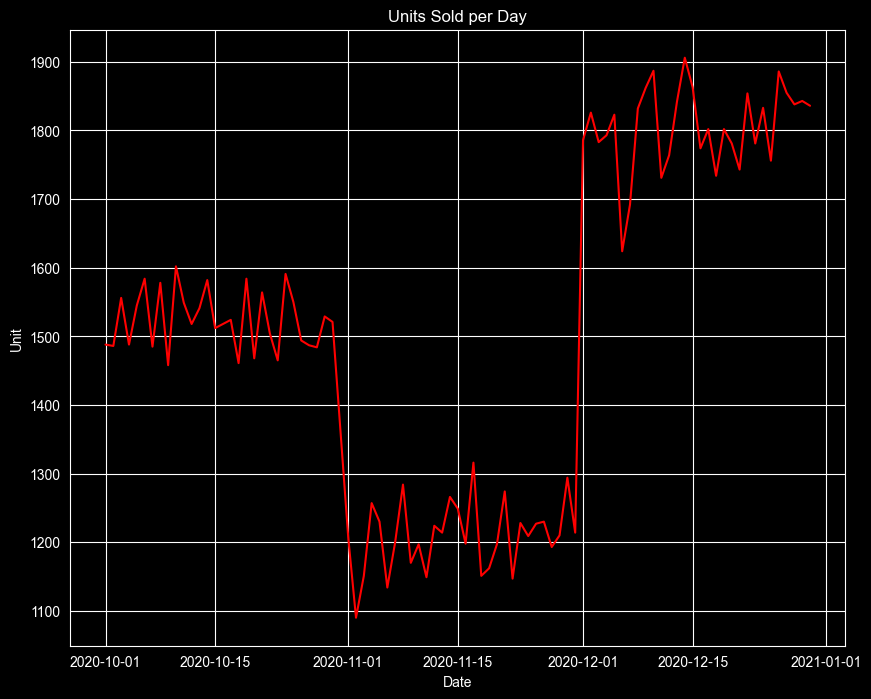

The number of units sold, varies based off of what month it is. The data shows that December had the highest volume of sales around 1800 sales per day, while November had the lowest volume around 1200 sales per day on average.


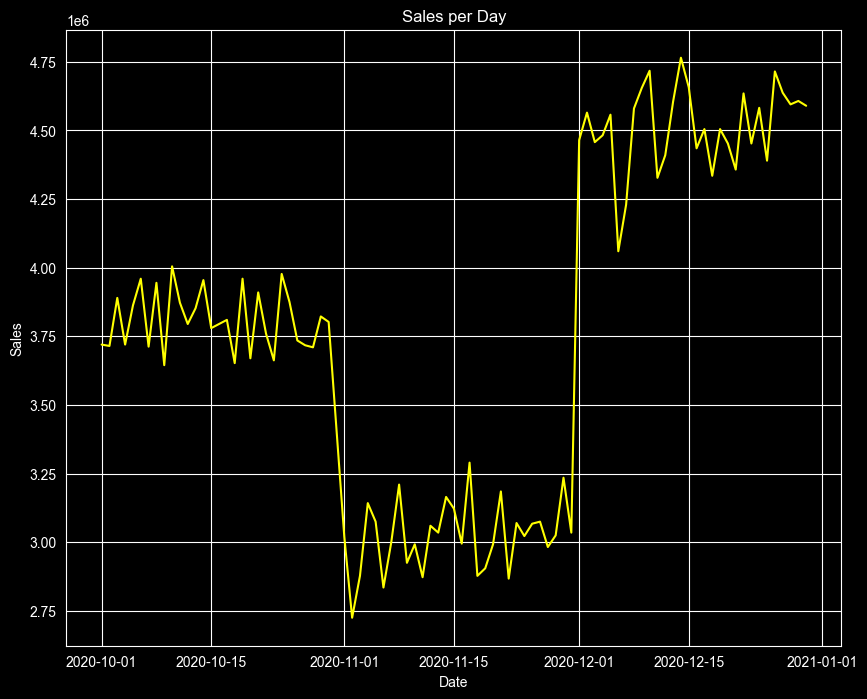

The sales per day, varies based off of what month it is. The data shows that December made the highest money made per day at around $4.5M per day, while November made the least money per day out of the three months at around $3M per day on average.


In [223]:
# 3. Visualize Overall Trends
# Plot the Date versus Unit and Date versus Sales line plot for the entire season.
# Sum up the values of Unit and Sales for each day
date_short = df['Date'].unique()

unit_sum = df.groupby('Date')['Unit'].sum()
unit_sum.index = pd.to_datetime(unit_sum.index, format='%d-%b-%y')
unit_sorted = unit_sum.sort_index()

sales_sum = df.groupby('Date')['Sales'].sum()
sales_sum.index = pd.to_datetime(sales_sum.index, format='%d-%b-%y')
sales_sorted = sales_sum.sort_index()

# Plot the date vs unit
plt.figure(figsize=(10, 8), dpi=100)
plt.plot(unit_sorted,color='red')
plt.title('Units Sold per Day')
plt.xlabel('Date')
plt.ylabel('Unit')
plt.show()

# Insights
print('The number of units sold, varies based off of what month it is. The data shows that December had the highest volume of sales '
      'around 1800 sales per day, while November had the lowest volume around 1200 sales per day on average.')

# Plot the date vs sales
plt.figure(figsize=(10, 8), dpi=100)
plt.plot(sales_sorted,color='yellow')
plt.title('Sales per Day')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

# Insights
print('The sales per day, varies based off of what month it is. The data shows that December made the highest money made per day '
      'at around $4.5M per day, while November made the least money per day out of the three months at around $3M per day on average.')

In [224]:
# 4.  Analyze Monthly Data
# Chunk this quarterly data into monthly data and perform the analysis.
# For each month, get the sub-DataFrame, using the loc feature of DataFrame, and pass the range by date.
df['Date'] = pd.to_datetime(df['Date'], format='%d-%b-%y')
monthly_df = df[['Date', 'Unit', 'Sales']].set_index('Date')

# October sub-dataframe
df_oct = monthly_df.loc['01-Oct-20':'31-Oct-20']
print(df_oct)

# November sub-dataframe
df_nov = monthly_df.loc['01-Nov-20':'30-Nov-20']
print(df_nov)

# December sub-dataframe
df_dec = monthly_df.loc['01-Dec-20':'31-Dec-20']
print(df_dec)

            Unit  Sales
Date                   
2020-10-01     8  20000
2020-10-01     8  20000
2020-10-01     4  10000
2020-10-01    15  37500
2020-10-01     3   7500
...          ...    ...
2020-10-30    12  30000
2020-10-30    15  37500
2020-10-30     7  17500
2020-10-30    10  25000
2020-10-30     5  12500

[2520 rows x 2 columns]
            Unit  Sales
Date                   
2020-11-01     4  10000
2020-11-01     6  15000
2020-11-01     4  10000
2020-11-01     7  17500
2020-11-01     8  20000
...          ...    ...
2020-11-30     9  22500
2020-11-30     9  22500
2020-11-30    10  25000
2020-11-30     9  22500
2020-11-30     2   5000

[2520 rows x 2 columns]
            Unit  Sales
Date                   
2020-12-01     9  22500
2020-12-01    11  27500
2020-12-01    15  37500
2020-12-01    13  32500
2020-12-01    13  32500
...          ...    ...
2020-12-30    14  35000
2020-12-30    15  37500
2020-12-30    15  37500
2020-12-30    11  27500
2020-12-30    13  32500

[2520 rows x 

In [225]:
# 5. Describe Data
# Describing the data will give you basic information such as count, mean, std (standard deviation), min, max and the quartiles.
# You will use the describe() command on the DataFrame to get it. All the values are for the entire three-month period.
# For each of the three months, you can invoke describe() on df_oct, df_nov, and df_dec.
print(df_oct.describe())
print(df_nov.describe())
print(df_dec.describe())

              Unit          Sales
count  2520.000000    2520.000000
mean     18.141270   45353.174603
std      11.944521   29861.302213
min       3.000000    7500.000000
25%       9.000000   22500.000000
50%      14.000000   35000.000000
75%      27.000000   67500.000000
max      50.000000  125000.000000
              Unit          Sales
count  2520.000000    2520.000000
mean     14.394048   35985.119048
std      10.946470   27366.175823
min       2.000000    5000.000000
25%       6.000000   15000.000000
50%      10.000000   25000.000000
75%      22.000000   55000.000000
max      45.000000  112500.000000
              Unit          Sales
count  2520.000000    2520.000000
mean     21.480952   53702.380952
std      14.554181   36385.451298
min       5.000000   12500.000000
25%      10.000000   25000.000000
50%      15.000000   37500.000000
75%      31.000000   77500.000000
max      65.000000  162500.000000


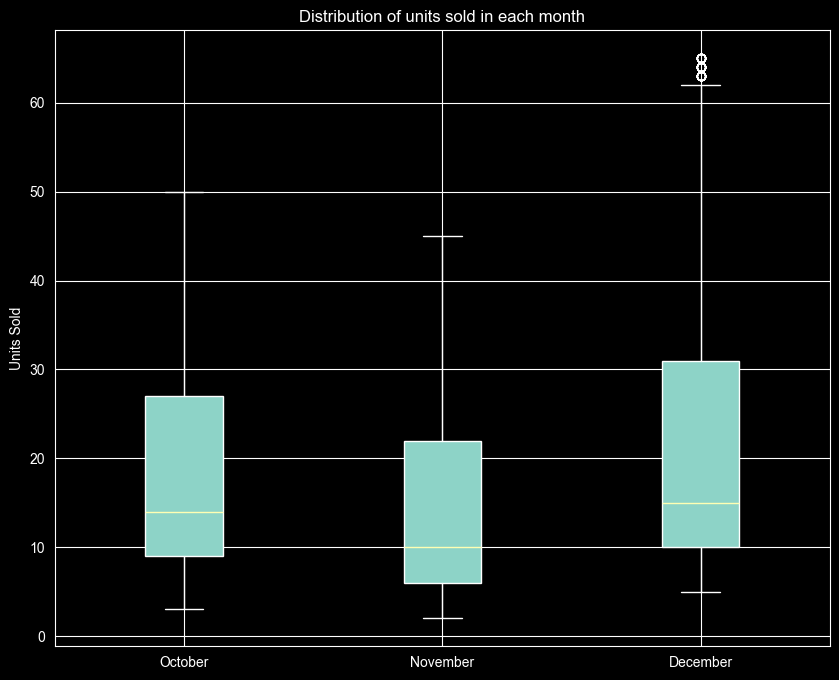

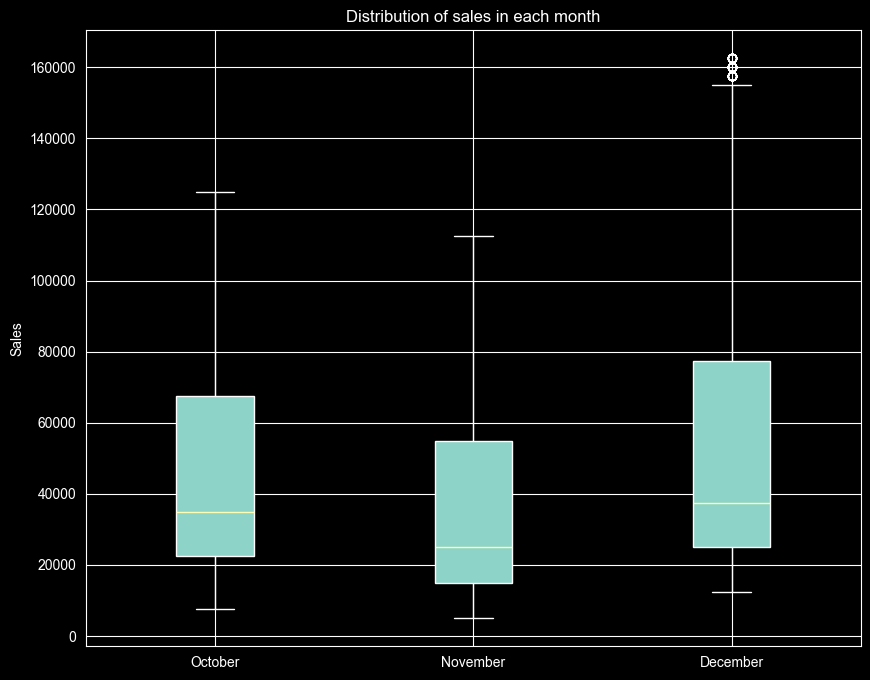

There is more of a distribution in December with a lot of outliers showing the December data might be skewed with those outliers. While the October data is closer together with no outliers and the medians of December and October are very close to each other.


In [226]:
# 6. Analyze Unit Data
# Unit Analysis
# You will use boxplots to visualize the distribution of units sold for each month.
units_df = [df_oct['Unit'].values, df_nov['Unit'].values, df_dec['Unit'].values]
sales_df = [df_oct['Sales'].values, df_nov['Sales'].values, df_dec['Sales'].values]
plt.figure(figsize=(10, 8), dpi=100)
plt.boxplot(units_df, tick_labels=['October', 'November', 'December'], patch_artist=True)
plt.ylabel('Units Sold')
plt.title("Distribution of units sold in each month")
plt.show()


# Sales Analysis
# You will explore the distribution of sales revenue for each month.
sales_df = [df_oct['Sales'].values, df_nov['Sales'].values, df_dec['Sales'].values]
plt.figure(figsize=(10, 8), dpi=100)
plt.boxplot(sales_df, tick_labels=['October', 'November', 'December'], patch_artist=True)
plt.ylabel('Sales')
plt.title("Distribution of sales in each month")
plt.show()


# Insights
print('There is more of a distribution in December with a lot of outliers showing the December '
      'data might be skewed with those outliers. While the October data is closer together with no outliers and the medians'
      ' of December and October are very close to each other.')

The total number of units sold is 136121
The total sales revenue is $340302500
The total number of units sold for October is 45716
The total number of units sold for November is 36273
The total number of units sold for December is 54132
The total sales for October is $114290000
The total sales for November is $90682500
The total sales for December is $135330000


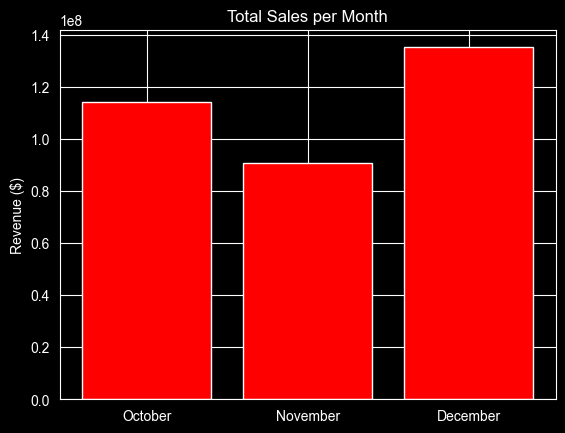

In [227]:
# 7. Explore Monthly Plots and Analysis
# Overall Unit and Sales figures
print(f'The total number of units sold is {df['Unit'].sum()}')
print(f'The total sales revenue is ${df['Sales'].sum()}')

# Units sold in October, November, and December
print(f'The total number of units sold for October is {df_oct['Unit'].sum()}')
print(f'The total number of units sold for November is {df_nov['Unit'].sum()}')
print(f'The total number of units sold for December is {df_dec['Unit'].sum()}')

# Sales numbers for October, November, and December
print(f'The total sales for October is ${df_oct['Sales'].sum()}')
print(f'The total sales for November is ${df_nov['Sales'].sum()}')
print(f'The total sales for December is ${df_dec['Sales'].sum()}')

# Consolidated 3-month sales plot
plt.bar(['October','November','December'],
        [df_oct['Sales'].sum(), df_nov['Sales'].sum(), df_dec['Sales'].sum()],
        color='red',
        align='center')
plt.ylabel('Revenue ($)')
plt.title('Total Sales per Month')
plt.show()

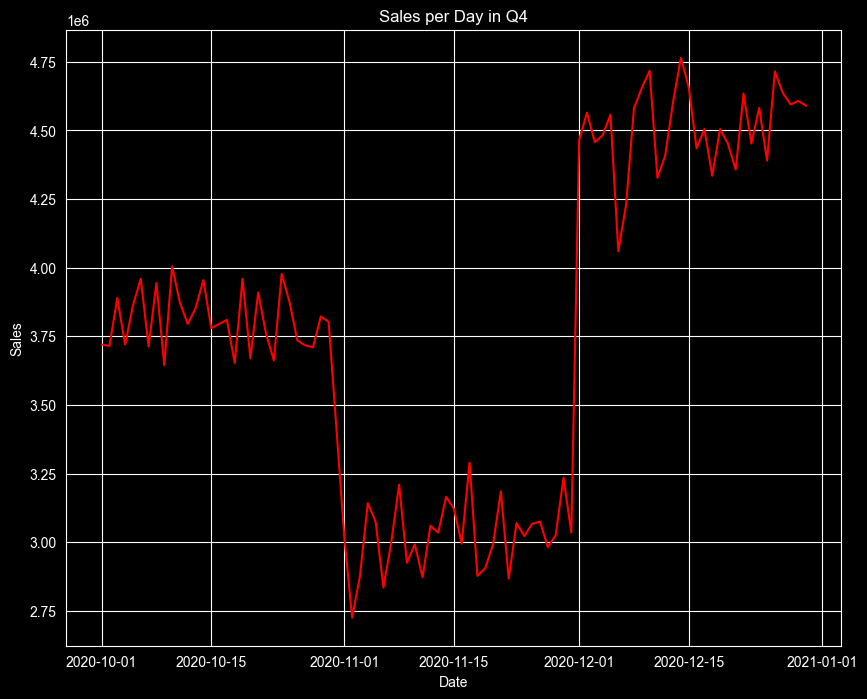

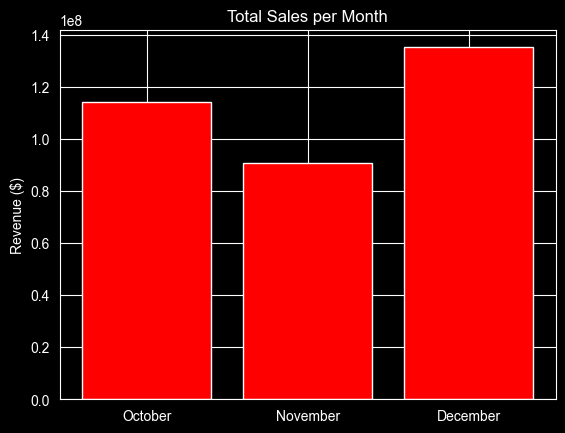

The average sales per month dropped by % 79.34 from October to November
The average sales per month increased by % 149.23 from November to December


In [228]:
# 8. Obtain a Comprehensive Snapshot - my guess is to do an overall analysis
# on the sales and units sold in respect to the 3 months

# Plot the date vs sales for the quarter
plt.figure(figsize=(10, 8), dpi=100)
plt.plot(sales_sorted,color='Red')
plt.title('Sales per Day in Q4')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

# Consolidated 3-month sales plot
plt.bar(['October','November','December'],
        [df_oct['Sales'].sum(), df_nov['Sales'].sum(), df_dec['Sales'].sum()],
        color='red',
        align='center')
plt.ylabel('Revenue ($)')
plt.title('Total Sales per Month')
plt.show()

# Revenue drop by percent
oct_avg_sales = df_oct.groupby('Date')['Sales'].mean().sum()
nov_avg_sales = df_nov.groupby('Date')['Sales'].mean().sum()
dec_avg_sales = df_dec.groupby('Date')['Sales'].mean().sum()
print(f'The average sales per month dropped by % {(nov_avg_sales/oct_avg_sales)*100:.2f} from October to November')
print(f'The average sales per month increased by % {(dec_avg_sales/nov_avg_sales)*100:.2f} from November to December')

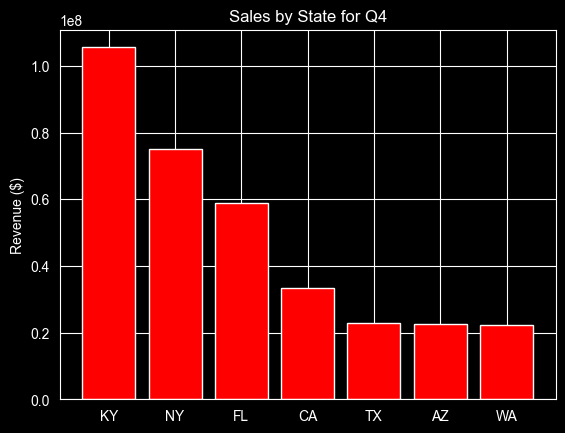

The bar graph shows that Kentucky had the highest amount of sales for the quarter, while Texas, Arizona, and Washington all had about the same as the lowest.


Based off this graph, the east side of the United States has an overall higher volume of sales than the central or west side of the United States.


In [229]:
# 9. Analyze Statewise Sales in the United States
states_df = df.groupby('State')[['Unit', 'Sales']].sum().sort_values(by='Unit', ascending=False)

# Plot the sales data as a bar graph in descending order
plt.bar(states_df.index,states_df['Sales'],color='red')
plt.ylabel('Revenue ($)')
plt.title('Sales by State for Q4')
plt.show()
print('The bar graph shows that Kentucky had the highest amount of sales for the quarter, while Texas, Arizona, and Washington all had about the same as the lowest.')

# Plot the number of units sold on a map
fig = px.choropleth(
    states_df,
    locations=states_df.index,
    locationmode='USA-states',
    color='Unit',
    scope='usa',
    color_continuous_scale='Turbo',
    labels={'Unit': 'Units Sold'}
)
fig.update_layout(title_text='Sales by State')
fig.show()
print('Based off this graph, the east side of the United States has an overall higher volume of sales than the central or west side of the United States.')

In [230]:
# 10. Conduct Groupwise Analysis
groups_df = df.groupby('Group')[['Unit', 'Sales']].sum()
print(groups_df)

          Unit     Sales
Group                   
Kids     34029  85072500
Men      34300  85750000
Seniors  33615  84037500
Women    34177  85442500


In [231]:
# 11. Explore Timewise Analysis
time_df = df.groupby('Time')[['Unit', 'Sales']].sum()
print(time_df)

            Unit      Sales
Time                       
Afternoon  45603  114007500
Evening    44835  112087500
Morning    45683  114207500
